# Automated Mental Health Feature Pipeline
## Dynamic Data Processing, Analysis & Feature Selection

This pipeline is now fully dynamic and modality-independent for core feature selection.

### Pipeline Stages Overview

**STAGE 1: DATA PREPARATION**
1. **Data Loading** — Load input dataset and validate shape/types
2. **Dynamic Column Split** — Detect label columns by name pattern; treat all other columns as features
3. **Label Encoding (One-Hot)** — Convert detected label column(s) to binary one-hot columns
4. **Exploratory Data Analysis (EDA)** — Global data quality checks, distribution, outlier, and correlation analysis

**STAGE 2: TWO-STAGE FEATURE REMOVAL**
5. **Variance Filtering** — Compute variance for all feature columns, remove near-constant features (`variance < 0.05`)
6. **Correlation Pair Detection** — Find highly redundant pairs with `|Pearson r| > 0.95`
7. **Consolidated Selection** — For each high-correlation pair, keep higher-variance feature and remove lower-variance feature
8. **Filtered Dataset Output** — Save final dataset and decision logs

**STAGE 3: REPORTING & VISUALIZATION**
9. **Selection Visualization** — Compare kept vs removed features and variance distribution
10. **Impact Analysis** — Show overall feature impact after selection
11. **Summary Report** — Export full run summary and key statistics

---

## Dynamic Design Rules

- **Label Detection Rule:** A column is treated as label if its name is `mental_health_label` or ends with `_label`
- **Feature Rule:** Every non-label column is a feature
- **No Fixed Indices:** No assumptions like "last column is label" or "47/38/18 modality split"
- **No Modality Dependency:** Core feature selection works even if modality naming is absent

---

## Key Parameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| **Stage 1 Variance Threshold** | `0.05` | Remove near-constant features |
| **Stage 2 Correlation Threshold** | `0.95` | Detect strongly redundant feature pairs |
| **Tie-Breaker Rule** | Keep higher-variance feature | Preserve more informative feature |
| **Removal Logic** | Additive across stages | Once removed, remains removed |

---

## Output Files

- `filtered_multimodal_dataset.csv` — Final dataset for model training
- `selected_features_list.csv` — Kept features ranked by variance
- `feature_removal_report.csv` — Detailed removal decisions
- `pipeline_summary_report.txt` — End-to-end summary report
- `variance_distribution.png` — Global feature variance distribution
- `feature_selection_visualization.png` — Kept vs removed summary chart
- `feature_impact_analysis.png` — Overall feature impact chart
- `top_features_heatmap.png` — Correlation heatmap of top selected features

---

## Why This Is Safer For Real Data

- Handles changing schemas without breaking
- Works when feature count increases/decreases
- Robust to column reordering
- Avoids reliance on modality-specific assumptions

In [35]:
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [36]:
# 2. LOAD DATASET
print("=" * 80)
print("STEP 1: LOADING DATASET")
print("=" * 80)

df = pd.read_csv('multimodal_mental_health_dataset_full.csv')

print(f"\n✓ Dataset loaded successfully!")
print(f"   Shape: {df.shape}")
print(f"   Total Rows: {df.shape[0]}")
print(f"   Total Columns: {df.shape[1]}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)

STEP 1: LOADING DATASET

✓ Dataset loaded successfully!
   Shape: (10000, 104)
   Total Rows: 10000
   Total Columns: 104

First 5 rows:
   total_word_count  unique_word_count  type_token_ratio  moving_avg_ttr  \
0          0.279041           1.010515         -0.580878       -0.525170   
1          1.004987          -0.064378          0.344902       -0.080087   
2          0.656797          -1.435901         -1.183266        0.494996   
3          0.853975           0.324166         -0.130143        0.096996   
4         -0.868582           0.116411          0.360169        1.718599   

   hapax_legomena_ratio  first_person_singular  first_person_plural  \
0             -0.571380              -0.924083            -2.612549   
1             -0.241380               1.433515             1.065794   
2             -0.165310              -0.687175             0.068351   
3              0.595157              -0.818221             2.092387   
4              0.866071              -0.103576     

In [37]:
# 3. ORGANIZE FEATURES DYNAMICALLY (NO MODALITY SPLIT)
print("\n" + "=" * 80)
print("STEP 2: ORGANIZING FEATURES (FULLY DYNAMIC)")
print("=" * 80)

all_columns = list(df.columns)
print(f"\nTotal columns in DataFrame: {len(all_columns)}")

# Detect label columns dynamically by name pattern
label_cols = [
    c for c in all_columns
    if c.lower() == 'mental_health_label' or c.lower().endswith('_label')
]

# Everything else is treated as model feature input
feature_columns = [c for c in all_columns if c not in label_cols]

# Keep these empty lists only for backward compatibility with downstream cells
text_cols = []
face_cols = []
voice_cols = []

print(f"\n✓ Dynamic split completed:")
print(f"   Feature columns: {len(feature_columns)}")
print(f"   Label columns:   {len(label_cols)}")

if len(label_cols) == 0:
    print("\n⚠ No raw label column detected by naming rule.")
    print("   Expected names like 'mental_health_label' or '*_label'.")

print(f"\nLabel columns: {label_cols}")
print(f"\nSample feature columns: {feature_columns[:8]}")
print("\nℹ Modality grouping is disabled for core dynamic pipeline.")


STEP 2: ORGANIZING FEATURES (FULLY DYNAMIC)

Total columns in DataFrame: 104

✓ Dynamic split completed:
   Feature columns: 103
   Label columns:   1

Label columns: ['mental_health_label']

Sample feature columns: ['total_word_count', 'unique_word_count', 'type_token_ratio', 'moving_avg_ttr', 'hapax_legomena_ratio', 'first_person_singular', 'first_person_plural', 'negative_frequency']

ℹ Modality grouping is disabled for core dynamic pipeline.


In [40]:
# STEP 3: ONE-HOT LABEL ENCODING
print("\n" + "=" * 80)
print("STEP 3: ENCODING CATEGORICAL LABELS - ONE-HOT ENCODING")
print("=" * 80)

import pandas as pd

# Re-detect raw label columns from current DataFrame for safe re-runs
label_cols = [
    c for c in df.columns
    if c.lower() == 'mental_health_label' or c.lower().endswith('_label')
]

if len(label_cols) == 0:
    print("\nℹ No raw *_label column found. Labels may already be one-hot encoded.")
    label_cols_encoded = [c for c in df.columns if c.lower().startswith('mental_health_label_')]
    label_cols = label_cols_encoded
    print(f"✓ Using existing encoded labels: {len(label_cols)} columns")
else:
    label_encoders = {}
    original_labels = df[label_cols].copy()
    label_cols_encoded = []

    for label in label_cols:
        # Force one-hot encoding for all labels (regardless of data type)
        # Numeric labels (0,1,2,3..) represent categories and should be encoded as binary columns
        one_hot_encoded = pd.get_dummies(df[label], prefix=label, drop_first=False)
        for col in one_hot_encoded.columns:
            df[col] = one_hot_encoded[col]
            label_cols_encoded.append(col)

        # Get categories for documentation
        categories = sorted(original_labels[label].unique())

        label_encoders[label] = {
            'categories': categories,
            'type': 'one-hot',
            'encoded_columns': list(one_hot_encoded.columns)
        }

    df = df.drop(columns=label_cols)
    label_cols = label_cols_encoded

    orig_label = original_labels.columns[0]
    categories = sorted(original_labels[orig_label].unique())
    print(f"\n  Column: {orig_label}")
    print(f"  Categories found ({len(categories)}): {categories}")
    print(f"\n  One-Hot Encoded into {len(label_cols)} binary columns:")
    for col in label_cols:
        print(f"    - {col}: [0 or 1]")
    print(f"\n✓ Done! Original 1 column → {len(label_cols)} binary columns")


STEP 3: ENCODING CATEGORICAL LABELS - ONE-HOT ENCODING

  Column: mental_health_label
  Categories found (6): ['Anxiety', 'Depression', 'Mania', 'Normal', 'Stress', 'Suicidal']

  One-Hot Encoded into 6 binary columns:
    - mental_health_label_Anxiety: [0 or 1]
    - mental_health_label_Depression: [0 or 1]
    - mental_health_label_Mania: [0 or 1]
    - mental_health_label_Normal: [0 or 1]
    - mental_health_label_Stress: [0 or 1]
    - mental_health_label_Suicidal: [0 or 1]

✓ Done! Original 1 column → 6 binary columns



STEP 4: EXPLORATORY DATA ANALYSIS (EDA) — DYNAMIC FEATURE-BASED

PART A: DATA QUALITY CHECKS
────────────────────────────────────────────────────────────────────────────────

✓ Missing Values:
   Total missing cells:  0 (out of 1,090,000)
   Missing value rate:   0.00%
   Columns with missing: 0 / 109
   ✓ NO MISSING VALUES - Dataset is complete!

✓ Duplicate Rows:
   Exact duplicates: 0 rows

✓ Data Types:
   Numeric columns:  103 / 109
   ✓ All features are numerical (continuous values)


────────────────────────────────────────────────────────────────────────────────
PART B: OVERALL FEATURE STATISTICS
────────────────────────────────────────────────────────────────────────────────

All 103 Features — Summary Statistics:
Feature                                Mean          Std          Min          Max        Range
──────────────────────────────────────────────────────────────────────────────────────────
total_word_count                   0.006700     1.008425    -3.753068     4.092

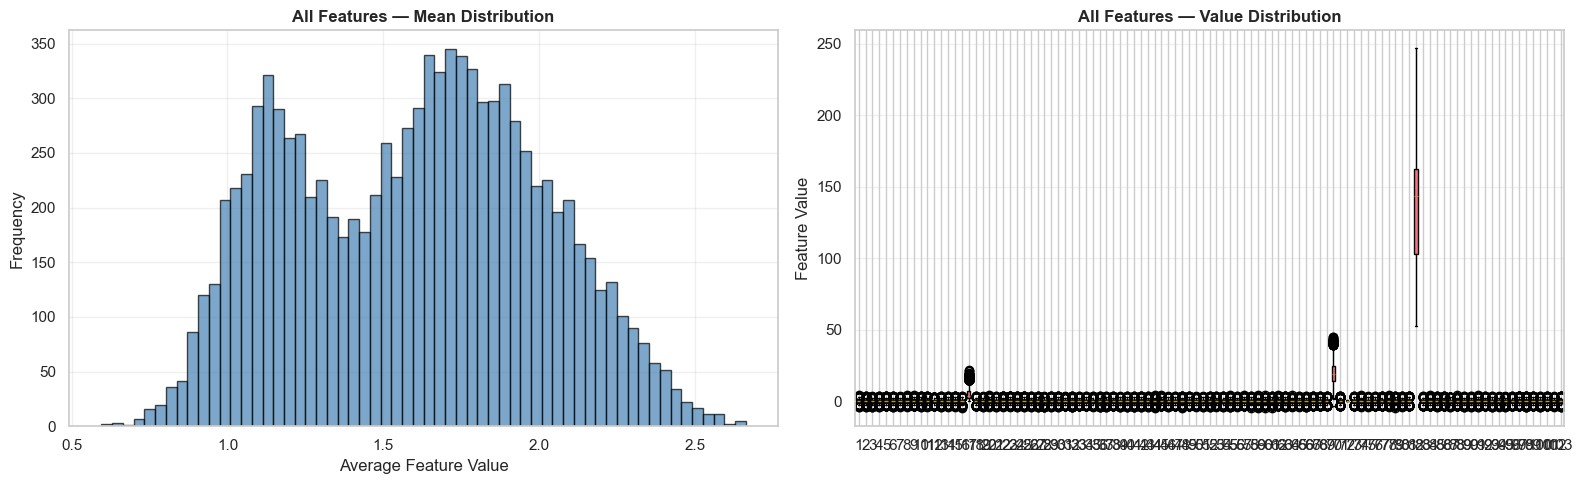

✓ Saved: eda_exploratory_analysis.png

✓ EDA COMPLETE — Dataset is ready for feature selection pipeline


In [41]:
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA) — DYNAMIC FEATURE-BASED
print("\n" + "=" * 80)
print("STEP 4: EXPLORATORY DATA ANALYSIS (EDA) — DYNAMIC FEATURE-BASED")
print("=" * 80)

# Dynamic core feature set
all_feature_cols = feature_columns.copy()

# ── PART A: DATA QUALITY CHECKS ────────────────────────────────────────────────
print("\nPART A: DATA QUALITY CHECKS")
print("─" * 80)

missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print(f"\n✓ Missing Values:")
print(f"   Total missing cells:  {total_missing} (out of {df.shape[0] * df.shape[1]:,})")
print(f"   Missing value rate:   {(total_missing / (df.shape[0] * df.shape[1]) * 100):.2f}%")
print(f"   Columns with missing: {(missing_values > 0).sum()} / {df.shape[1]}")
if (missing_values > 0).sum() > 0:
    print(f"   ⚠ Columns affected: {missing_values[missing_values > 0].to_dict()}")
else:
    print("   ✓ NO MISSING VALUES - Dataset is complete!")

duplicate_rows = df.duplicated().sum()
print(f"\n✓ Duplicate Rows:")
print(f"   Exact duplicates: {duplicate_rows} rows")

numeric_cols = df.select_dtypes(include=[np.number]).shape[1]
print(f"\n✓ Data Types:")
print(f"   Numeric columns:  {numeric_cols} / {df.shape[1]}")
print("   ✓ All features are numerical (continuous values)")

# ── PART B: OVERALL FEATURE STATISTICS ─────────────────────────────────────────
print("\n\n" + "─" * 80)
print("PART B: OVERALL FEATURE STATISTICS")
print("─" * 80)

print(f"\nAll {len(all_feature_cols)} Features — Summary Statistics:")
print(f"{'Feature':<30} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12} {'Range':>12}")
print("─" * 90)

for feature in all_feature_cols:
    mean = df[feature].mean()
    std = df[feature].std()
    min_val = df[feature].min()
    max_val = df[feature].max()
    range_val = max_val - min_val
    print(f"{feature:<30} {mean:>12.6f} {std:>12.6f} {min_val:>12.6f} {max_val:>12.6f} {range_val:>12.6f}")

# ── PART C: GLOBAL OUTLIERS & SHAPE ────────────────────────────────────────────
print("\n\n" + "─" * 80)
print("PART C: GLOBAL OUTLIERS & DISTRIBUTION SHAPE")
print("─" * 80)

feature_df = df[all_feature_cols]
q1 = feature_df.quantile(0.25)
q3 = feature_df.quantile(0.75)
iqr = q3 - q1
outliers = ((feature_df < (q1 - 1.5 * iqr)) | (feature_df > (q3 + 1.5 * iqr))).sum()

print(f"\nOutliers (IQR method):")
print(f"  • Total outlier cells:      {outliers.sum()} out of {feature_df.shape[0] * feature_df.shape[1]:,}")
print(f"  • Outlier-affected features: {(outliers > 0).sum()} / {feature_df.shape[1]}")

skew_vals = feature_df.skew()
kurt_vals = feature_df.kurtosis()
print(f"\nDistribution Shape:")
print(f"  • Mean skewness: {skew_vals.mean():.4f}")
print(f"  • Mean kurtosis: {kurt_vals.mean():.4f}")

# ── PART D: VALUE RANGES & SCALING ─────────────────────────────────────────────
print("\n\n" + "─" * 80)
print("PART D: VALUE RANGES & SCALING REQUIREMENTS")
print("─" * 80)

all_values = feature_df.values.flatten()
print(f"\nGlobal Features Statistics:")
print(f"  • Overall min:       {all_values.min():.6f}")
print(f"  • Overall max:       {all_values.max():.6f}")
print(f"  • Overall mean:      {all_values.mean():.6f}")
print(f"  • Overall std dev:   {np.std(all_values):.6f}")
print(f"  • Value range span:  {all_values.max() - all_values.min():.6f}")

print(f"\nNote: For model training, consider:")
print(f"  ✓ StandardScaler (mean=0, std=1): recommended for most ML algorithms")
print(f"  ✓ MinMaxScaler (range [0,1]):     good for neural networks")
print(f"  ✓ RobustScaler:                    if outliers are significant")

# ── PART E: GLOBAL CORRELATION PATTERNS ────────────────────────────────────────
print("\n\n" + "─" * 80)
print("PART E: GLOBAL CORRELATION PATTERNS (Before Feature Selection)")
print("─" * 80)

corr_matrix = feature_df.corr().abs()
corr_pairs = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]

print(f"\nGlobal Correlation Summary:")
print(f"  • Mean absolute correlation:   {np.mean(corr_pairs):.4f}")
print(f"  • Median absolute correlation: {np.median(corr_pairs):.4f}")
print(f"  • Max absolute correlation:    {np.max(corr_pairs):.4f}")
print(f"  • Pairs > 0.95:                {(corr_pairs > 0.95).sum()}")

# ── VISUALIZATIONS ──────────────────────────────────────────────────────────────
print("\n\n" + "─" * 80)
print("VISUALIZATION: EDA Summary Charts")
print("─" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(feature_df.mean(axis=1), bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('All Features — Mean Distribution', fontweight='bold')
axes[0].set_xlabel('Average Feature Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(feature_df.values, patch_artist=True)
axes[1].set_title('All Features — Value Distribution', fontweight='bold')
axes[1].set_ylabel('Feature Value')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eda_exploratory_analysis.png")

print("\n" + "=" * 80)
print("✓ EDA COMPLETE — Dataset is ready for feature selection pipeline")
print("=" * 80)


STEP 5: VARIANCE CALCULATION & LOW-VARIANCE FILTERING

Calculating variance for 103 features...

Variance Statistics (All 103 Features):
  • Mean:    15.8839
  • Median:  1.0028
  • Min:     0.0384
  • Max:     1470.9548
  • Std Dev: 144.1629

────────────────────────────────────────────────────────────────────────────────
FIXED ABSOLUTE THRESHOLD: variance < 0.05
  → Features below this are near-constant and carry minimal information
────────────────────────────────────────────────────────────────────────────────

Top 10 Features with HIGHEST Variance (most informative — will be KEPT):
  #    Feature                                 Variance  Decision
  ────────────────────────────────────────────────────────────
   1.  speech_rate_wpm                      1470.954776  kept
   2.  blink_rate                             50.972212  kept
   3.  sadness_word_freq                      14.985503  kept
   4.  mean_head_velocity                      1.028971  kept
   5.  intensity_mean       

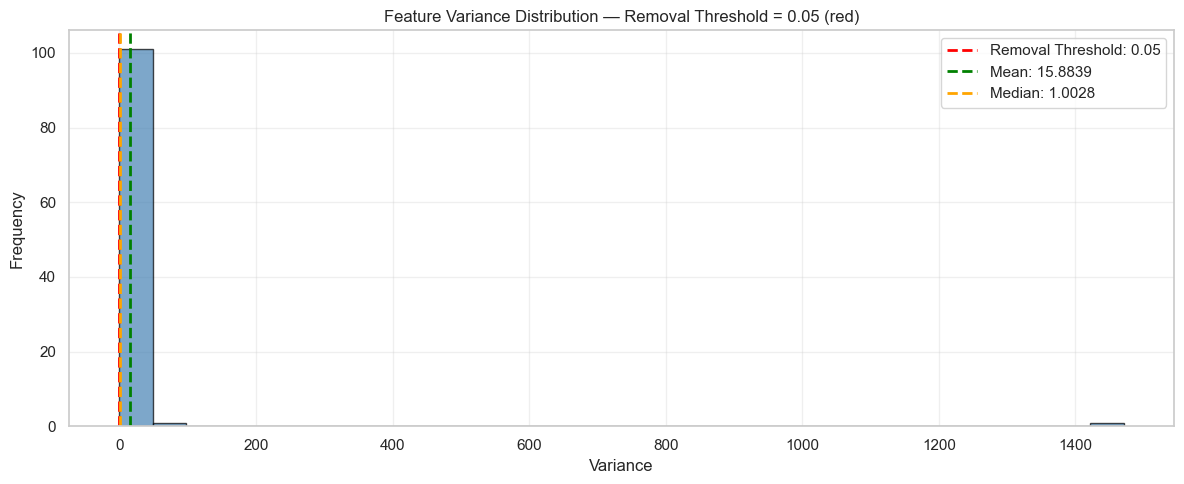

✓ Saved: variance_distribution.png


In [46]:
# STEP 5: VARIANCE CALCULATION & LOW-VARIANCE FILTERING (TWO-STAGE REMOVAL)
print("\n" + "=" * 80)
print("STEP 5: VARIANCE CALCULATION & LOW-VARIANCE FILTERING")
print("=" * 80)

# Dynamic core: use ALL detected feature columns (modality-independent)
all_feature_cols = feature_columns.copy()

# Calculate variance for each feature
feature_variances = {}
print(f"\nCalculating variance for {len(all_feature_cols)} features...")

for feature in all_feature_cols:
    feature_variances[feature] = df[feature].var()

sorted_variances = sorted(feature_variances.items(), key=lambda x: x[1], reverse=True)

median_variance = np.median(list(feature_variances.values()))
mean_variance   = np.mean(list(feature_variances.values()))

print(f"\nVariance Statistics (All {len(all_feature_cols)} Features):")
print(f"  • Mean:    {mean_variance:.4f}")
print(f"  • Median:  {median_variance:.4f}")
print(f"  • Min:     {np.min(list(feature_variances.values())):.4f}")
print(f"  • Max:     {np.max(list(feature_variances.values())):.4f}")
print(f"  • Std Dev: {np.std(list(feature_variances.values())):.4f}")

# ── FIXED ABSOLUTE THRESHOLD ───────────────────────────────────────────────────
# Rule: remove a feature ONLY if its variance < 0.05
variance_threshold    = 0.05
low_variance_features = [f for f, v in feature_variances.items() if v < variance_threshold]

print(f"\n{'─'*80}")
print(f"FIXED ABSOLUTE THRESHOLD: variance < {variance_threshold}")
print(f"  → Features below this are near-constant and carry minimal information")
print(f"{'─'*80}")

# ── ALL FEATURES WITH VARIANCE VALUE ──────────────────────────────────────────
print(f"\nTop 10 Features with HIGHEST Variance (most informative — will be KEPT):")
print(f"  {'#':<4} {'Feature':<35} {'Variance':>12}  Decision")
print(f"  {'─'*60}")
for i, (feature, var) in enumerate(sorted_variances[:10], 1):
    print(f"  {i:>2}.  {feature:<35} {var:>12.6f}  kept")

print(f"\nBottom 15 Features by Variance (showing removal boundary at {variance_threshold}):")
print(f"  {'#':<4} {'Feature':<35} {'Variance':>12}  Decision")
print(f"  {'─'*65}")
for i, (feature, var) in enumerate(sorted_variances[-15:], 1):
    status = "← REMOVED  (< 0.05)" if var < variance_threshold else "  kept"
    print(f"  {i:>2}.  {feature:<35} {var:>12.6f}  {status}")

# ── STAGE 1: REMOVAL SUMMARY ────────────────────────────────────────────────────
print(f"\n\n{'─'*80}")
print(f"STAGE 1 RESULT: Features with variance < {variance_threshold}")
print(f"{'─'*80}")
print(f"\n  Features removed: {len(low_variance_features)}")
if low_variance_features:
    for feat in sorted(low_variance_features, key=lambda f: feature_variances[f]):
        print(f"    • {feat:<35}  var={feature_variances[feat]:.6f}  ← REMOVED")
else:
    print(f"    ✓ No features fall below the {variance_threshold} threshold — all features kept")

# Filter features: remove low-variance, keep remaining for Stage 2
feature_cols = [f for f in all_feature_cols if f not in low_variance_features]

print(f"\n✓ Features after Stage 1 (Low-Variance Removal):")
print(f"  • Original:  {len(all_feature_cols)} features")
print(f"  • Removed:   {len(low_variance_features)} features  (variance < {variance_threshold})")
print(f"  • Remaining: {len(feature_cols)} features  (for Stage 2 correlation analysis)")

# Visualize variance distribution
fig, ax = plt.subplots(figsize=(12, 5))
variances = list(feature_variances.values())
ax.hist(variances, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(variance_threshold, color='red',    linestyle='--', linewidth=2, label=f'Removal Threshold: {variance_threshold}')
ax.axvline(mean_variance,      color='green',  linestyle='--', linewidth=2, label=f'Mean: {mean_variance:.4f}')
ax.axvline(median_variance,    color='orange', linestyle='--', linewidth=2, label=f'Median: {median_variance:.4f}')
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')
ax.set_title(f'Feature Variance Distribution — Removal Threshold = {variance_threshold} (red)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: variance_distribution.png")

In [47]:
# PRE-ANALYSIS: CONFIGURATION OVERVIEW
print("\n" + "=" * 80)
print("PRE-ANALYSIS: STAGE 2 — CORRELATION PAIR DETECTION CONFIGURATION")
print("=" * 80)

CORRELATION_THRESHOLD = 0.95
total_pairs = len(feature_cols) * (len(feature_cols) - 1) // 2

print(f"\n  Two-Stage Removal Pipeline:")
print(f"    ✓ Stage 1: Low-variance filtering (DONE — {len(low_variance_features)} removed)")
print(f"    → Stage 2: Correlation-based removal (IN PROGRESS)")

print(f"\n  Correlation Method:    Pearson (absolute value |r|) across ALL features")
print(f"  Correlation Threshold: {CORRELATION_THRESHOLD}  (pairs above this are redundant)")
print(f"  Tie-Breaker Rule:      Keep the feature with HIGHER variance from each pair")
print(f"                         (higher variance = more information spread = more discriminative)")

print(f"\n  Feature Pool (Post-Stage 1):")
print(f"    Total : {len(feature_cols):>4} features")
print(f"    Pairs : {total_pairs:,} unique feature pairs to scan")

print(f"\n  Upcoming Steps:")
print(f"    Step 6 → Feature-to-Feature Correlation  (find redundant pairs > {CORRELATION_THRESHOLD})")
print(f"    Step 7 → Feature Selection (Two-Stage)   (consolidate Stage 1 + Stage 2 decisions)")


PRE-ANALYSIS: STAGE 2 — CORRELATION PAIR DETECTION CONFIGURATION

  Two-Stage Removal Pipeline:
    ✓ Stage 1: Low-variance filtering (DONE — 1 removed)
    → Stage 2: Correlation-based removal (IN PROGRESS)

  Correlation Method:    Pearson (absolute value |r|) across ALL features
  Correlation Threshold: 0.95  (pairs above this are redundant)
  Tie-Breaker Rule:      Keep the feature with HIGHER variance from each pair
                         (higher variance = more information spread = more discriminative)

  Feature Pool (Post-Stage 1):
    Total :  102 features
    Pairs : 5,151 unique feature pairs to scan

  Upcoming Steps:
    Step 6 → Feature-to-Feature Correlation  (find redundant pairs > 0.95)
    Step 7 → Feature Selection (Two-Stage)   (consolidate Stage 1 + Stage 2 decisions)


In [48]:
# STEP 6: FIND HIGHLY CORRELATED FEATURE PAIRS (STAGE 2)
print("\n" + "=" * 80)
print(f"STEP 6: FINDING HIGHLY CORRELATED FEATURE PAIRS (THRESHOLD: {CORRELATION_THRESHOLD})")
print("=" * 80)

# Calculate correlation matrix between remaining features AFTER Stage 1 filtering
print(f"\nCalculating correlation matrix for {len(feature_cols)} features (post-Stage 1)...")
feature_corr_matrix = df[feature_cols].corr().abs()

correlated_pairs = []

print(f"\nScanning for pairs with |correlation| > {CORRELATION_THRESHOLD}...")

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        feat1 = feature_cols[i]
        feat2 = feature_cols[j]
        corr_value = feature_corr_matrix.loc[feat1, feat2]

        if corr_value > CORRELATION_THRESHOLD:
            correlated_pairs.append({
                'Feature_1': feat1,
                'Feature_2': feat2,
                'Correlation': corr_value,
                'Variance_1': feature_variances[feat1],
                'Variance_2': feature_variances[feat2]
            })

print(f"\n✓ Found {len(correlated_pairs)} correlated pairs (> {CORRELATION_THRESHOLD})!")

if len(correlated_pairs) > 0:
    pairs_df = pd.DataFrame(correlated_pairs).sort_values('Correlation', ascending=False)
    print(f"\nTop 20 Highly Correlated Pairs (for Stage 2 removal):")
    print(pairs_df.head(20).to_string(index=False))
else:
    print(f"\nℹ No correlated pairs found above {CORRELATION_THRESHOLD} threshold!")


STEP 6: FINDING HIGHLY CORRELATED FEATURE PAIRS (THRESHOLD: 0.95)

Calculating correlation matrix for 102 features (post-Stage 1)...

Scanning for pairs with |correlation| > 0.95...

✓ Found 0 correlated pairs (> 0.95)!

ℹ No correlated pairs found above 0.95 threshold!


In [49]:
# STEP 7: FEATURE SELECTION — TWO-STAGE REMOVAL CONSOLIDATION
print("\n" + "=" * 80)
print("STEP 7: FEATURE SELECTION — TWO-STAGE REMOVAL CONSOLIDATION")
print("=" * 80)

print(f"\n  Stage 1 Summary: Low-Variance Filtering")
print(f"    • Features removed: {len(low_variance_features)}")
print(f"    • Absolute threshold: variance < {variance_threshold:.6f}")

print(f"\n  Stage 2 Summary: Correlation-Based Removal")
print(f"    • Correlated pairs found: {len(correlated_pairs)}")
print(f"    • Will select higher-variance feature from each pair")

# Build removal set: Start with Stage 1, then add Stage 2 removals
features_to_remove = set(low_variance_features)  # Stage 1 removals
removal_reasons = []

# Record Stage 1 removals
print(f"\n\n{'─'*80}")
print("STAGE 1 REMOVALS: LOW-VARIANCE FEATURES")
print(f"{'─'*80}\n")

for idx, feat in enumerate(sorted(low_variance_features, key=lambda f: feature_variances[f]), 1):
    removal_reasons.append({
        'Index': idx,
        'Feature': feat,
        'Removed_In_Stage': 'Stage 1 - Low Variance',
        'Reason': f'Variance={feature_variances[feat]:.6f} (< {variance_threshold:.6f} threshold)',
        'Variance_Value': feature_variances[feat],
        'Pair_Correlation': None
    })
    print(f"  {idx:>2}. {feat:<30} var={feature_variances[feat]:.6f}")

# Record Stage 2 removals (correlation-based)
print(f"\n\n{'─'*80}")
print("STAGE 2 REMOVALS: CORRELATION-BASED (Lower-Variance from Pairs)")
print(f"{'─'*80}\n")

stage2_idx = 1
for pair_idx, pair in enumerate(correlated_pairs, 1):
    feat1 = pair['Feature_1']
    feat2 = pair['Feature_2']
    corr_between = pair['Correlation']
    var1 = feature_variances[feat1]
    var2 = feature_variances[feat2]

    if var1 >= var2:
        feature_to_keep = feat1
        feature_to_remove = feat2
        var_keep = var1
        var_remove = var2
    else:
        feature_to_keep = feat2
        feature_to_remove = feat1
        var_keep = var2
        var_remove = var1

    # Only add to removal if not already marked in Stage 1
    if feature_to_remove not in features_to_remove:
        features_to_remove.add(feature_to_remove)
        removal_reasons.append({
            'Index': len(low_variance_features) + stage2_idx,
            'Feature': feature_to_remove,
            'Removed_In_Stage': 'Stage 2 - Correlation',
            'Reason': f'Lower var ({var_remove:.6f}) vs {feature_to_keep} ({var_keep:.6f}), r={corr_between:.6f}',
            'Variance_Value': var_remove,
            'Pair_Correlation': corr_between
        })
        print(f"  {stage2_idx:>2}. {feature_to_remove:<30} (correlation={corr_between:.6f}, variance={var_remove:.6f})")
        stage2_idx += 1

print(f"\n\n{'='*80}")
print("FINAL FEATURE SELECTION RESULTS")
print(f"{'='*80}")
print(f"\n✓ Total Features Overall:  {len(all_feature_cols)}")
print(f"  • Stage 1 Removed:       {len(low_variance_features)} (low variance)")
print(f"  • Stage 2 Removed:       {len([r for r in removal_reasons if r['Removed_In_Stage'] == 'Stage 2 - Correlation'])} (correlation)")
print(f"  • Total Removed:         {len(features_to_remove)}")
print(f"  • Final Kept:            {len(all_feature_cols) - len(features_to_remove)}")


STEP 7: FEATURE SELECTION — TWO-STAGE REMOVAL CONSOLIDATION

  Stage 1 Summary: Low-Variance Filtering
    • Features removed: 1
    • Absolute threshold: variance < 0.050000

  Stage 2 Summary: Correlation-Based Removal
    • Correlated pairs found: 0
    • Will select higher-variance feature from each pair


────────────────────────────────────────────────────────────────────────────────
STAGE 1 REMOVALS: LOW-VARIANCE FEATURES
────────────────────────────────────────────────────────────────────────────────

   1. eye_contact_ratio              var=0.038391


────────────────────────────────────────────────────────────────────────────────
STAGE 2 REMOVALS: CORRELATION-BASED (Lower-Variance from Pairs)
────────────────────────────────────────────────────────────────────────────────



FINAL FEATURE SELECTION RESULTS

✓ Total Features Overall:  103
  • Stage 1 Removed:       1 (low variance)
  • Stage 2 Removed:       0 (correlation)
  • Total Removed:         1
  • Final Kept:        

In [50]:
# STEP 8: CREATE FILTERED DATASET (using both Stage 1 & 2 removals)
print("\n" + "=" * 80)
print("STEP 8: CREATE FILTERED DATASET")
print("=" * 80)

# Build final selected features list (exclude all Stage 1 + Stage 2 removals)
selected_features = [f for f in all_feature_cols if f not in features_to_remove]

print(f"\n✓ Two-Stage Removal Summary:")
print(f"  • Stage 1 Low-Variance:  {len(low_variance_features)} removed")
print(f"  • Stage 2 Correlation:   {len([r for r in removal_reasons if r['Removed_In_Stage'] == 'Stage 2 - Correlation'])} removed")
print(f"  • Total Removed:         {len(features_to_remove)} features")
print(f"  • Selected to Keep:      {len(selected_features)} features")

filtered_df = df[selected_features + label_cols].copy()

print(f"\n  Original Dataset Shape: {df.shape}")
print(f"  Filtered Dataset Shape: {filtered_df.shape}")
print(f"  Columns Removed:        {df.shape[1] - filtered_df.shape[1]}")

# Save filtered dataset
filtered_df.to_csv('filtered_multimodal_dataset.csv', index=False)
print(f"\n✓ Saved: filtered_multimodal_dataset.csv")

# Save selected features with variance
selected_features_df = pd.DataFrame({
    'Feature_Name': selected_features,
    'Variance': [feature_variances[f] for f in selected_features]
}).sort_values('Variance', ascending=False)

selected_features_df.to_csv('selected_features_list.csv', index=False)
print(f"✓ Saved: selected_features_list.csv")

# Save all removal decisions (both stages)
removal_report_df = pd.DataFrame(removal_reasons)
removal_report_df.to_csv('feature_removal_report.csv', index=False)
print(f"✓ Saved: feature_removal_report.csv")

print(f"\nTop 10 Selected Features by Variance:")
print(selected_features_df.head(10).to_string(index=False))


STEP 8: CREATE FILTERED DATASET

✓ Two-Stage Removal Summary:
  • Stage 1 Low-Variance:  1 removed
  • Stage 2 Correlation:   0 removed
  • Total Removed:         1 features
  • Selected to Keep:      102 features

  Original Dataset Shape: (10000, 109)
  Filtered Dataset Shape: (10000, 108)
  Columns Removed:        1

✓ Saved: filtered_multimodal_dataset.csv
✓ Saved: selected_features_list.csv
✓ Saved: feature_removal_report.csv

Top 10 Selected Features by Variance:
          Feature_Name    Variance
       speech_rate_wpm 1470.954776
            blink_rate   50.972212
     sadness_word_freq   14.985503
    mean_head_velocity    1.028971
        intensity_mean    1.023192
   au12_mean_amplitude    1.021633
   pause_duration_mean    1.021316
   voiced_segment_rate    1.021013
            verb_ratio    1.020690
facial_emotional_range    1.020349


In [51]:
# STEP 9: CREATE FILTERED DATASET
print("\n" + "=" * 80)
print("STEP 9: CREATING FILTERED DATASET")
print("=" * 80)

selected_features = [f for f in feature_cols if f not in features_to_remove]

print(f"\n✓ Selected {len(selected_features)} features to keep")
print(f"  Removed  {len(features_to_remove)} redundant features")

filtered_df = df[selected_features + label_cols].copy()

print(f"\n  Original Dataset Shape: {df.shape}")
print(f"  Filtered Dataset Shape: {filtered_df.shape}")
print(f"  Columns Removed:        {df.shape[1] - filtered_df.shape[1]}")

# Save filtered dataset
filtered_df.to_csv('filtered_multimodal_dataset.csv', index=False)
print(f"\n✓ Saved: filtered_multimodal_dataset.csv")

# Save selected features with variance
selected_features_df = pd.DataFrame({
    'Feature_Name': selected_features,
    'Variance': [feature_variances[f] for f in selected_features]
}).sort_values('Variance', ascending=False)

selected_features_df.to_csv('selected_features_list.csv', index=False)
print(f"✓ Saved: selected_features_list.csv")

# Save removal report
removal_report_df = pd.DataFrame(removal_reasons)
removal_report_df.to_csv('feature_removal_report.csv', index=False)
print(f"✓ Saved: feature_removal_report.csv")

print(f"\nTop 10 Selected Features by Variance:")
print(selected_features_df.head(10).to_string(index=False))



STEP 9: CREATING FILTERED DATASET

✓ Selected 102 features to keep
  Removed  1 redundant features

  Original Dataset Shape: (10000, 109)
  Filtered Dataset Shape: (10000, 108)
  Columns Removed:        1

✓ Saved: filtered_multimodal_dataset.csv
✓ Saved: selected_features_list.csv
✓ Saved: feature_removal_report.csv

Top 10 Selected Features by Variance:
          Feature_Name    Variance
       speech_rate_wpm 1470.954776
            blink_rate   50.972212
     sadness_word_freq   14.985503
    mean_head_velocity    1.028971
        intensity_mean    1.023192
   au12_mean_amplitude    1.021633
   pause_duration_mean    1.021316
   voiced_segment_rate    1.021013
            verb_ratio    1.020690
facial_emotional_range    1.020349



STEP 10: VISUALIZING FEATURE SELECTION RESULTS


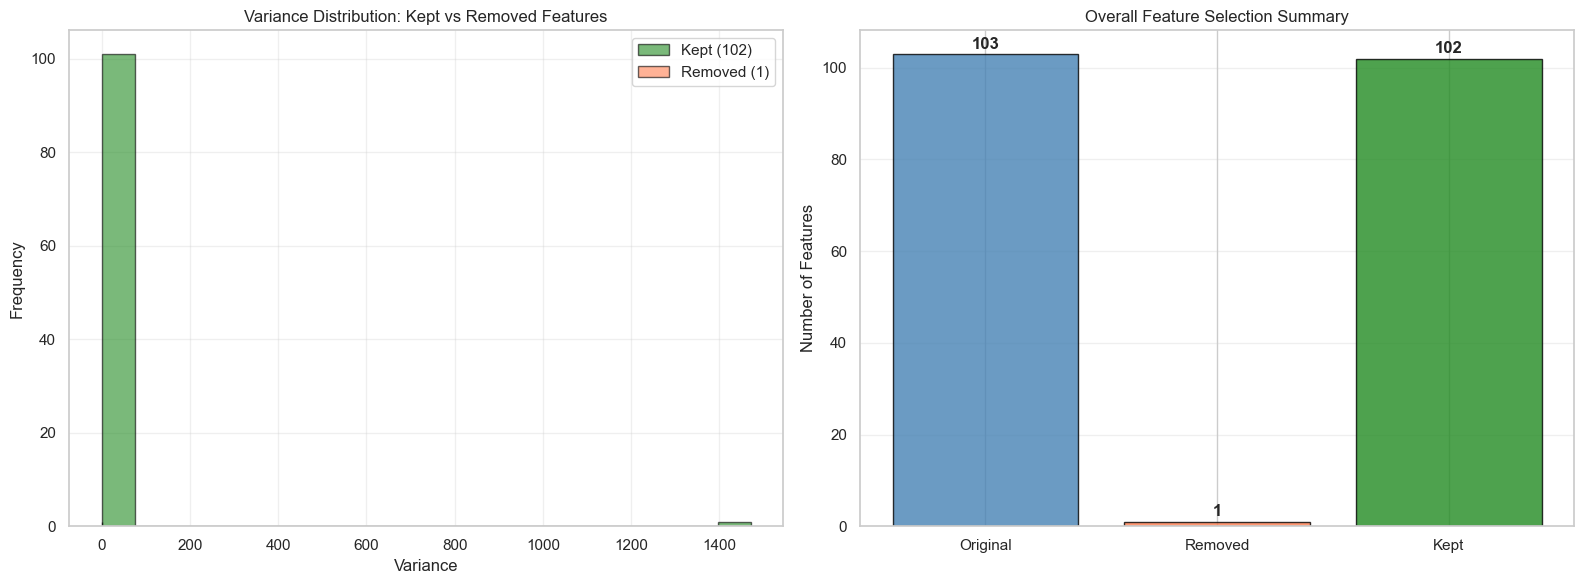

✓ Saved: feature_selection_visualization.png


In [52]:
# STEP 10: VISUALIZE FEATURE SELECTION RESULTS
print("\n" + "=" * 80)
print("STEP 10: VISUALIZING FEATURE SELECTION RESULTS")
print("=" * 80)

kept_features = selected_features
removed_features = list(features_to_remove)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variance distribution — Kept vs Removed
ax1 = axes[0]
kept_variances = [feature_variances[f] for f in kept_features]
removed_variances = [feature_variances[f] for f in removed_features] if removed_features else []
ax1.hist(kept_variances, bins=20, color='forestgreen', edgecolor='black', alpha=0.6, label=f'Kept ({len(kept_features)})')
if removed_variances:
    ax1.hist(removed_variances, bins=20, color='coral', edgecolor='black', alpha=0.6, label=f'Removed ({len(removed_features)})')
ax1.set_xlabel('Variance')
ax1.set_ylabel('Frequency')
ax1.set_title('Variance Distribution: Kept vs Removed Features')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Overall feature count before/after selection
ax2 = axes[1]
categories = ['Original', 'Removed', 'Kept']
counts = [len(all_feature_cols), len(removed_features), len(kept_features)]
colors = ['steelblue', 'coral', 'forestgreen']

bars = ax2.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Number of Features')
ax2.set_title('Overall Feature Selection Summary')
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_selection_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_selection_visualization.png")

In [53]:
# STEP 11: GENERATE COMPREHENSIVE SUMMARY REPORT
print("\n" + "=" * 80)
print("STEP 11: GENERATING COMPREHENSIVE SUMMARY REPORT")
print("=" * 80)

summary_report = f"""
{'='*80}
MULTIMODAL MENTAL HEALTH DATASET PIPELINE - EXECUTION SUMMARY
{'='*80}

DATASET INFORMATION
{'='*80}
• Total Records:            {df.shape[0]:,}
• Original Features:        {len(all_feature_cols)}
• Total Columns (w/ label): {df.shape[1]}

DYNAMIC FEATURE ORGANIZATION
{'='*80}
• Total Feature Columns: {len(feature_columns)}
• Label Columns:         {len(label_cols)}
  {', '.join(label_cols)}

VARIANCE STATISTICS — All {len(all_feature_cols)} Features
{'='*80}
• Mean Variance:   {np.mean(list(feature_variances.values())):.6f}
• Median Variance: {np.median(list(feature_variances.values())):.6f}
• Min Variance:    {np.min(list(feature_variances.values())):.6f}
• Max Variance:    {np.max(list(feature_variances.values())):.6f}
• Stage 1 Rule:    Remove feature if variance < {variance_threshold}

CORRELATION ANALYSIS RESULTS
{'='*80}
• Method:                 Pearson (absolute value)
• Threshold:              {CORRELATION_THRESHOLD}
• Features Scanned:       {len(feature_cols)}
• Correlated Pairs Found: {len(correlated_pairs)}
• Features Removed:       {len(features_to_remove)}
• Features Kept:          {len(all_feature_cols) - len(features_to_remove)}

FINAL DATASET
{'='*80}
• Original Shape:  {df.shape}
• Filtered Shape:  {filtered_df.shape}
• Columns Removed: {df.shape[1] - filtered_df.shape[1]}

PIPELINE PARAMETERS
{'='*80}
• Label Encoding:           One-Hot (no ordinal implication)
• Correlation Threshold:    {CORRELATION_THRESHOLD}
• Feature Selection Method: Two-stage (variance filter + correlation redundancy)
• Core Strategy:            Dynamic all-feature processing

OUTPUT FILES
{'='*80}
✓ filtered_multimodal_dataset.csv      — Clean dataset for model training
✓ selected_features_list.csv           — {len(selected_features)} kept features with variance values
✓ feature_removal_report.csv           — Removal decisions with variance comparison
✓ pipeline_summary_report.txt          — This report
✓ variance_distribution.png            — Variance distribution (all feature columns)
✓ feature_selection_visualization.png  — Kept vs removed + overall feature counts
✓ top_features_heatmap.png             — Top 15 features inter-correlation heatmap
✓ feature_impact_analysis.png          — Overall feature impact analysis

{'='*80}
PIPELINE COMPLETED SUCCESSFULLY
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(summary_report)

with open('pipeline_summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("✓ Saved: pipeline_summary_report.txt")


STEP 11: GENERATING COMPREHENSIVE SUMMARY REPORT

MULTIMODAL MENTAL HEALTH DATASET PIPELINE - EXECUTION SUMMARY

DATASET INFORMATION
• Total Records:            10,000
• Original Features:        103
• Total Columns (w/ label): 109

DYNAMIC FEATURE ORGANIZATION
• Total Feature Columns: 103
• Label Columns:         6
  mental_health_label_Anxiety, mental_health_label_Depression, mental_health_label_Mania, mental_health_label_Normal, mental_health_label_Stress, mental_health_label_Suicidal

VARIANCE STATISTICS — All 103 Features
• Mean Variance:   15.883888
• Median Variance: 1.002756
• Min Variance:    0.038391
• Max Variance:    1470.954776
• Stage 1 Rule:    Remove feature if variance < 0.05

CORRELATION ANALYSIS RESULTS
• Method:                 Pearson (absolute value)
• Threshold:              0.95
• Features Scanned:       102
• Correlated Pairs Found: 0
• Features Removed:       1
• Features Kept:          102

FINAL DATASET
• Original Shape:  (10000, 109)
• Filtered Shape:  (10

In [58]:
# STEP 12: DETAILED REMOVAL DECISIONS TABLE
print("\n" + "=" * 80)
print("STEP 12: ALL FEATURE REMOVAL DECISIONS (Detailed)")
print("=" * 80)

detailed_removal_df = pd.DataFrame(removal_reasons)

print(f"\nTotal Removal Decisions: {len(detailed_removal_df)}")
print("Each row shows one feature removed with stage and reason\n")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 80)

# Prefer current schema, but stay robust if schema changes later
preferred_cols = [
    'Index',
    'Feature',
    'Removed_In_Stage',
    'Reason',
    'Variance_Value',
    'Pair_Correlation'
]

display_cols = [c for c in preferred_cols if c in detailed_removal_df.columns]

if len(display_cols) == 0:
    print("⚠ No expected columns found. Showing all available columns:")
    print(detailed_removal_df.to_string(index=False))
else:
    # Sort by index if available; otherwise keep natural order
    if 'Index' in detailed_removal_df.columns:
        detailed_removal_df = detailed_removal_df.sort_values('Index')
    print(detailed_removal_df[display_cols].to_string(index=False))

print("\n✓ All decisions saved to: feature_removal_report.csv")


STEP 12: ALL FEATURE REMOVAL DECISIONS (Detailed)

Total Removal Decisions: 1
Each row shows one feature removed with stage and reason

 Index           Feature       Removed_In_Stage                                   Reason  Variance_Value Pair_Correlation
     1 eye_contact_ratio Stage 1 - Low Variance Variance=0.038391 (< 0.050000 threshold)        0.038391             None

✓ All decisions saved to: feature_removal_report.csv



STEP 13: CORRELATION HEATMAP — TOP 15 SELECTED FEATURES

Top 15 selected features by variance:
   1. speech_rate_wpm  (var=1470.954776)
   2. blink_rate  (var=50.972212)
   3. sadness_word_freq  (var=14.985503)
   4. mean_head_velocity  (var=1.028971)
   5. intensity_mean  (var=1.023192)
   6. au12_mean_amplitude  (var=1.021633)
   7. pause_duration_mean  (var=1.021316)
   8. voiced_segment_rate  (var=1.021013)
   9. verb_ratio  (var=1.020690)
  10. facial_emotional_range  (var=1.020349)
  11. modal_verb_frequency  (var=1.020158)
  12. present_focus_ratio  (var=1.019143)
  13. total_word_count  (var=1.016922)
  14. mfcc_3  (var=1.016778)
  15. au15_mean_amplitude  (var=1.015289)


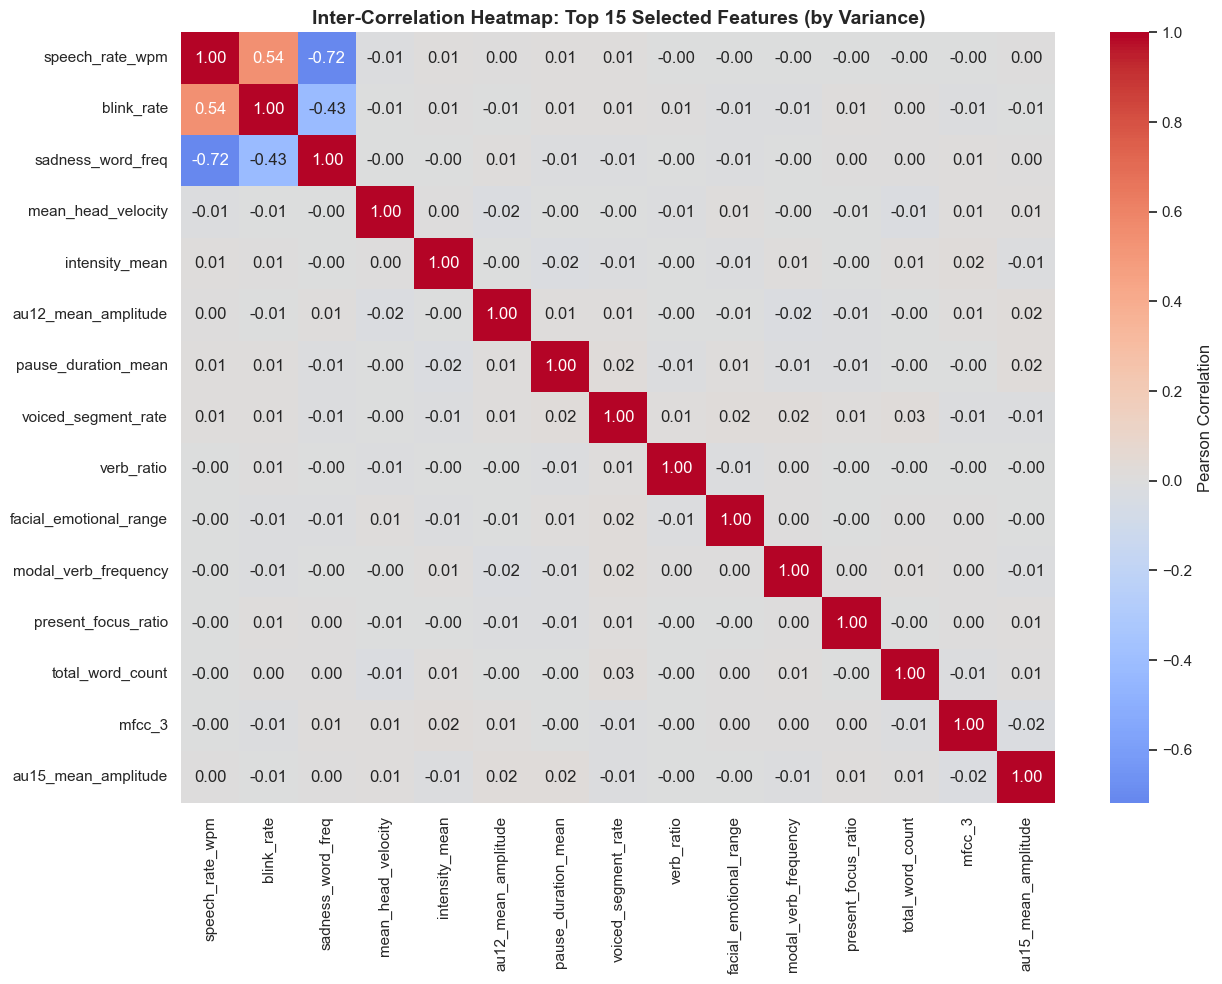


✓ Saved: top_features_heatmap.png


In [59]:
# STEP 13: TOP SELECTED FEATURES — INTER-CORRELATION HEATMAP
print("\n" + "=" * 80)
print("STEP 13: CORRELATION HEATMAP — TOP 15 SELECTED FEATURES")
print("=" * 80)

# Top 15 features by variance (highest variance = most informative)
top_features = selected_features_df.head(15)['Feature_Name'].tolist()

print(f"\nTop 15 selected features by variance:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:>2}. {f}  (var={feature_variances[f]:.6f})")

# Show their mutual (feature-to-feature) correlations
top_feature_corr = df[top_features].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(top_feature_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Inter-Correlation Heatmap: Top 15 Selected Features (by Variance)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_features_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: top_features_heatmap.png")



STEP 14: OVERALL FEATURE IMPACT ANALYSIS

Overall Feature Impact Summary:
         Category  Count     Rate_%
Original Features    103 100.000000
 Removed Features      1   0.970874
    Kept Features    102  99.029126


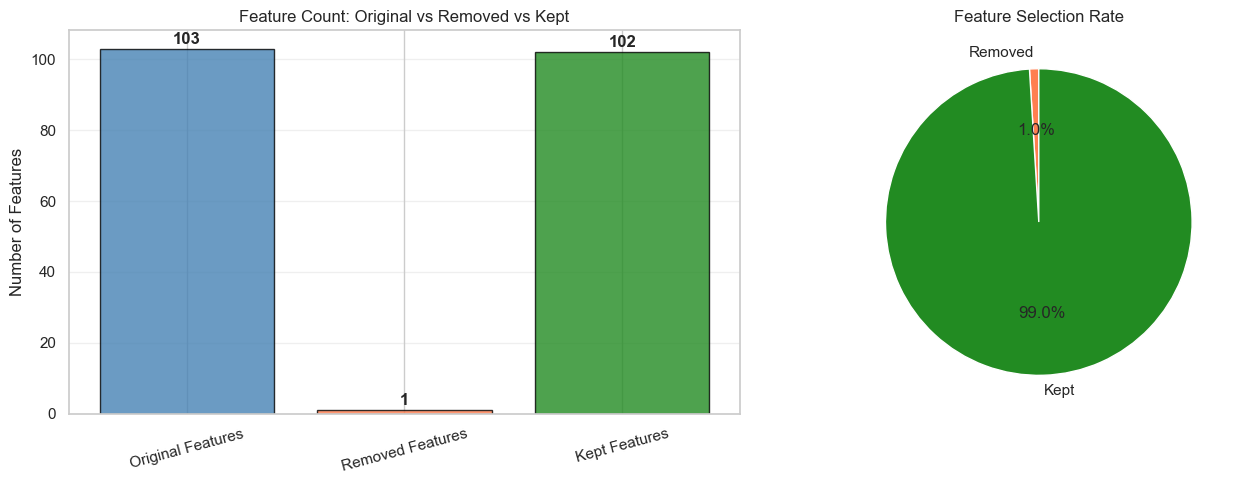

✓ Saved: feature_impact_analysis.png

Lowest-variance removed features (top 10):
   1. eye_contact_ratio                        var=0.038391


In [60]:
# STEP 14: OVERALL FEATURE IMPACT ANALYSIS
print("\n" + "=" * 80)
print("STEP 14: OVERALL FEATURE IMPACT ANALYSIS")
print("=" * 80)

removed_features = sorted(list(features_to_remove), key=lambda f: feature_variances[f])
kept_features = selected_features

impact_summary = pd.DataFrame([
    {
        'Category': 'Original Features',
        'Count': len(all_feature_cols),
        'Rate_%': 100.0
    },
    {
        'Category': 'Removed Features',
        'Count': len(removed_features),
        'Rate_%': (len(removed_features) / len(all_feature_cols) * 100) if len(all_feature_cols) else 0.0
    },
    {
        'Category': 'Kept Features',
        'Count': len(kept_features),
        'Rate_%': (len(kept_features) / len(all_feature_cols) * 100) if len(all_feature_cols) else 0.0
    }
])

print("\nOverall Feature Impact Summary:")
print(impact_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Overall counts
ax1 = axes[0]
bars = ax1.bar(impact_summary['Category'], impact_summary['Count'],
               color=['steelblue', 'coral', 'forestgreen'], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Number of Features')
ax1.set_title('Feature Count: Original vs Removed vs Kept')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Rate pie
ax2 = axes[1]
ax2.pie(
    [len(removed_features), len(kept_features)],
    labels=['Removed', 'Kept'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['coral', 'forestgreen'],
    wedgeprops={'edgecolor': 'white'}
)
ax2.set_title('Feature Selection Rate')

plt.tight_layout()
plt.savefig('feature_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_impact_analysis.png")

if len(removed_features) > 0:
    print("\nLowest-variance removed features (top 10):")
    for i, f in enumerate(removed_features[:10], 1):
        print(f"  {i:>2}. {f:<40} var={feature_variances[f]:.6f}")
else:
    print("\nNo features were removed in this run.")

## Pipeline Execution Complete! ✓

### Steps Completed
1. **✓ Data Loaded** — Source CSV loaded and validated
2. **✓ Dynamic Column Split** — Label columns detected by name rule; all remaining columns treated as features
3. **✓ Labels Encoded** — Raw label column(s) one-hot encoded
4. **✓ EDA Complete** — Data quality, global distribution, outliers, and global correlation analysis
5. **✓ Variances Calculated** — Variance computed for all dynamic feature columns
6. **✓ Correlated Pairs Found** — Feature pairs with |r| > 0.95 identified
7. **✓ Features Selected** — Two-stage removal (low variance + correlation tie-break)
8. **✓ Dataset Filtered** — Final feature set saved to CSV
9. **✓ Visualizations Generated** — Variance distribution, selection summary, and feature impact charts
10. **✓ Summary Report Saved** — pipeline_summary_report.txt

### Generated Files
- filtered_multimodal_dataset.csv — Ready for model training
- selected_features_list.csv — Kept features sorted by variance
- feature_removal_report.csv — Detailed removal decisions
- pipeline_summary_report.txt — Complete summary with parameters and statistics
- variance_distribution.png — Variance distribution for all feature columns
- feature_selection_visualization.png — Kept vs removed + overall feature counts
- top_features_heatmap.png — Inter-correlation heatmap of top 15 selected features
- feature_impact_analysis.png — Overall feature impact analysis

### Key Configuration
- **Pipeline Type:** Fully dynamic, modality-independent
- **Label Detection Rule:** `mental_health_label` or any `*_label`
- **Feature Rule:** Every non-label column is a feature
- **Stage 1 Rule:** Remove features with variance < 0.05
- **Stage 2 Rule:** Remove lower-variance feature from each pair where |r| > 0.95

### Next Steps
Use filtered_multimodal_dataset.csv for:
- Model training
- Feature scaling (StandardScaler / MinMaxScaler)
- Cross-validation and model evaluation
- Hyperparameter tuning

Review pipeline_summary_report.txt for the complete run summary.

## Model Training, Comparison, and Best Model Export

This section trains multiple candidate algorithms on the updated filtered dataset, compares accuracy, selects the best-performing model, and saves it to a `.pkl` file.

In [1]:
# STEP 15: TRAIN & COMPARE MULTIPLE MODELS, SAVE BEST AS PKL
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    XGBClassifier = None
    xgboost_available = False

print("\n" + "=" * 80)
print("STEP 15: MODEL TRAINING & COMPARISON")
print("=" * 80)

# Strictly use filtered dataset from the pipeline output
workspace = Path.cwd()
filtered_path = workspace / 'filtered_multimodal_dataset.csv'

if not filtered_path.exists():
    raise FileNotFoundError(
        "filtered_multimodal_dataset.csv not found. Run Step 8 first to generate the filtered dataset."
    )

model_df = pd.read_csv(filtered_path)
print(f"\n✓ Loaded dataset: {filtered_path.name}")
print(f"✓ Dataset shape: {model_df.shape}")

# Detect target column(s)
one_hot_label_cols = [c for c in model_df.columns if c.lower().startswith('mental_health_label_')]
raw_label_cols = [c for c in model_df.columns if c.lower() == 'mental_health_label' or c.lower().endswith('_label')]

if len(one_hot_label_cols) > 0:
    y = model_df[one_hot_label_cols].idxmax(axis=1).str.replace('mental_health_label_', '', regex=False)
    feature_cols_for_model = [c for c in model_df.columns if c not in one_hot_label_cols]
    target_info = f"one-hot labels detected ({len(one_hot_label_cols)} columns)"
elif len(raw_label_cols) > 0:
    target_col = raw_label_cols[0]
    y = model_df[target_col].astype(str)
    feature_cols_for_model = [c for c in model_df.columns if c != target_col]
    target_info = f"single label column detected ({target_col})"
else:
    raise ValueError("No label column found. Expected 'mental_health_label', '*_label', or one-hot label columns.")

X = model_df[feature_cols_for_model].copy()

print(f"✓ Target detection: {target_info}")
print(f"✓ Feature matrix shape: {X.shape}")
print(f"✓ Number of classes: {y.nunique()}")

# Numeric-encoded labels are required for some algorithms (e.g., XGBoost)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train/validation split
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X, y, y_encoded, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

# Candidate models
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2500, random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVC_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(C=2.0, kernel='rbf', class_weight='balanced', random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ])
}

if xgboost_available:
    num_classes = int(len(label_encoder.classes_))
    objective = 'multi:softprob' if num_classes > 2 else 'binary:logistic'
    eval_metric = 'mlogloss' if num_classes > 2 else 'logloss'

    models['XGBoost'] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective=objective,
        eval_metric=eval_metric,
        random_state=42,
        n_jobs=-1
    )
    print("✓ XGBoost detected and added to candidate models.")
else:
    print("ℹ XGBoost is not installed. Install it with: pip install xgboost")

results = []
trained_models = {}

print("\nTraining candidate models...")
for model_name, model in models.items():
    start_t = time.time()
    try:
        if model_name == 'XGBoost':
            model.fit(X_train, y_train_enc)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test_enc, preds)
            f1m = f1_score(y_test_enc, preds, average='macro')
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)
            f1m = f1_score(y_test, preds, average='macro')

        elapsed = time.time() - start_t

        results.append({
            'Model': model_name,
            'Accuracy': acc,
            'F1_Macro': f1m,
            'Train_Time_Sec': elapsed
        })
        trained_models[model_name] = model

        print(f"  ✓ {model_name:<20} Accuracy={acc:.4f} | F1-macro={f1m:.4f} | Time={elapsed:.2f}s")

    except Exception as e:
        print(f"  ✗ {model_name:<20} failed: {e}")

if len(results) == 0:
    raise RuntimeError("All models failed. Please check dataset/labels and dependencies.")

# Compare and pick best model by Accuracy, then F1_Macro
results_df = pd.DataFrame(results).sort_values(
    by=['Accuracy', 'F1_Macro'], ascending=False
).reset_index(drop=True)

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_acc = float(results_df.loc[0, 'Accuracy'])
best_f1 = float(results_df.loc[0, 'F1_Macro'])

print("\n" + "-" * 80)
print("MODEL COMPARISON RESULTS")
print("-" * 80)
print(results_df.to_string(index=False))

print("\n" + "=" * 80)
print(f"BEST MODEL: {best_model_name}")
print(f"Accuracy : {best_acc:.4f}")
print(f"F1-Macro : {best_f1:.4f}")
print("=" * 80)

# Save outputs
joblib.dump(best_model, 'best_model.pkl')
results_df.to_csv('model_comparison_results.csv', index=False)

label_encoder_file = None
if best_model_name == 'XGBoost':
    label_encoder_file = 'best_model_label_encoder.pkl'
    joblib.dump(label_encoder, label_encoder_file)
    print(f"✓ Saved: {label_encoder_file} (required to decode predicted class IDs)")

metadata = {
    'dataset_used': filtered_path.name,
    'best_model_name': best_model_name,
    'best_accuracy': best_acc,
    'best_f1_macro': best_f1,
    'n_features': int(X.shape[1]),
    'n_classes': int(y.nunique()),
    'class_labels': [str(c) for c in label_encoder.classes_],
    'xgboost_available': bool(xgboost_available),
    'label_encoder_file': label_encoder_file,
    'feature_columns': feature_cols_for_model,
    'models_tested': results_df['Model'].tolist()
}

with open('best_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print("\n✓ Saved: best_model.pkl")
print("✓ Saved: model_comparison_results.csv")
print("✓ Saved: best_model_metadata.json")


STEP 15: MODEL TRAINING & COMPARISON

✓ Loaded dataset: filtered_multimodal_dataset.csv
✓ Dataset shape: (10000, 108)
✓ Target detection: one-hot labels detected (6 columns)
✓ Feature matrix shape: (10000, 102)
✓ Number of classes: 6

Train size: 8000 rows
Test size:  2000 rows
✓ XGBoost detected and added to candidate models.

Training candidate models...
  ✓ LogisticRegression   Accuracy=0.7755 | F1-macro=0.7751 | Time=0.34s
  ✓ RandomForest         Accuracy=0.7855 | F1-macro=0.7806 | Time=7.09s
  ✓ ExtraTrees           Accuracy=0.7780 | F1-macro=0.7730 | Time=2.26s
  ✓ GradientBoosting     Accuracy=0.7885 | F1-macro=0.7881 | Time=144.16s
  ✓ SVC_RBF              Accuracy=0.7465 | F1-macro=0.7448 | Time=8.38s
  ✓ KNN                  Accuracy=0.3925 | F1-macro=0.3825 | Time=3.32s
  ✓ XGBoost              Accuracy=0.7820 | F1-macro=0.7813 | Time=44.30s

--------------------------------------------------------------------------------
MODEL COMPARISON RESULTS
--------------------------